# How many attention heads does a task need? Built by hand

This notebook rebuilds the whole project from scratch, in small steps you can do yourself.
Every section has the same five parts:

1. **Idea**: what we are doing, in plain words.
2. **By hand**: the same thing on numbers small enough for pen and paper.
3. **Your turn**: step-by-step instructions to write the code yourself. Try it in a new cell
   before reading the solution.
4. **Solution and check**: short code, and a check that it matches the by-hand numbers.
5. **Real result**: what the full experiments (hundreds of saved runs) found.

Everything here runs on a CPU in about two minutes. Only numpy, PyTorch and matplotlib are
needed for sections 1 to 8; the real-result cells read the saved runs in `results/`.

| section | what you build |
|---|---|
| 1 | the task: a memory, a query, and four answers |
| 2 | one attention head |
| 3 | why the task needs exactly $R$ heads (one head, one equation) |
| 4 | a layer of many heads, trained from scratch |
| 5 | the supply valve on each head |
| 6 | the collateral value: what nobody else can cover |
| 7 | the collateral rule, running during training |
| 8 | what the full experiments found |
| 9 | backup heads when heads can fail |
| 10 | a second circuit: two-layer induction |
| 11 | what holds and what does not |

In [1]:
import glob, pickle, sys
from math import comb
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

RED, GREY = "#b2182b", "#888888"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})
torch.set_num_threads(4)
print("ready")

ready


## 1. The task

**Idea.** A memory has $N$ slots. Slot $j$ holds a random vector $c_j$ (its *content*). A
query arrives holding a position $p$. The model must return the contents found $\delta_1,
\dots, \delta_R$ slots ahead of $p$, wrapping around like a clock:

$$\text{answer} = (c_{p+\delta_1},\ \dots,\ c_{p+\delta_R}), \qquad \text{positions taken mod } N.$$

**By hand.** $N = 8$ slots, $R = 2$ offsets $\delta = (1, 5)$, query $p = 6$:
$(6 + 1) \bmod 8 = 7$ and $(6 + 5) \bmod 8 = 3$. The answer is $(c_7, c_3)$.

**Your turn.** Write `make_batch(B)` that returns `query, memory, answer`:
1. Draw `B` positions `p` uniformly from `0..N-1`.
2. Draw contents `content` of shape `(B, N, m)` from a standard normal.
3. The query is the one-hot vector of `p`: shape `(B, N)`.
4. The memory row for slot `j` is `[one-hot of j, content of j]`: shape `(B, N, N + m)`.
5. The answer stacks `content[(p + delta_r) mod N]` for each offset: shape `(B, R * m)`.

In [2]:
N, R, m = 8, 2, 4                                   # slots, offsets, content size
OFFSETS = [1 + r * N // R for r in range(R)]          # evenly spread: (1, 5)


def make_batch(B, gen=None):
    p = torch.randint(0, N, (B,), generator=gen)
    content = torch.randn(B, N, m, generator=gen)
    query = F.one_hot(p, N).float()
    memory = torch.cat([torch.eye(N).expand(B, N, N), content], 2)
    idx = (p[:, None] + torch.tensor(OFFSETS)[None]) % N
    answer = torch.gather(content, 1, idx[..., None].expand(B, R, m)).reshape(B, R * m)
    return query, memory, answer, p, content


q, mem, ans, p, content = make_batch(1, torch.Generator().manual_seed(0))
p0 = int(p[0])
print("offsets", OFFSETS, "  query position p =", p0)
for r, d in enumerate(OFFSETS):
    slot = (p0 + d) % N
    print(f"  ({p0} + {d}) mod {N} = {slot}:  answer block {r} equals content of slot {slot}:",
          torch.equal(ans[0, r * m:(r + 1) * m], content[0, slot]))

offsets [1, 5]   query position p = 4
  (4 + 1) mod 8 = 5:  answer block 0 equals content of slot 5: True
  (4 + 5) mod 8 = 1:  answer block 1 equals content of slot 1: True


## 2. One attention head

**Idea.** A head turns the query into a *query vector* $q$, each memory slot into a *key*
$k_j$ and a *value* $v_j$. It scores each slot by $q \cdot k_j$, turns the scores into
weights that are positive and sum to one (the softmax), and returns the weighted average of
the values:

$$a_j = \frac{e^{q\cdot k_j}}{\sum_i e^{q \cdot k_i}}, \qquad \text{output} = \sum_j a_j\, v_j .$$

**By hand.** Three slots with scores $(2, 0, 0)$: $e^2 = 7.389$, $e^0 = 1$, so the weights are
$7.389/9.389 = 0.787$ and $1/9.389 = 0.107$ twice. With values $(10, 20, 30)$ the output is
$0.787 \cdot 10 + 0.107 \cdot 20 + 0.107 \cdot 30 = 7.87 + 2.13 + 3.20 = 13.2$: mostly slot 1,
a little of the others. (Keep three decimals: rounding the weights to 0.79 and 0.11 first
gives 13.4, which is wrong.)

**Your turn.** Write `attend(scores, values)`: softmax the scores, then return the weighted sum.
Check it gives 13.2 on the example above.

In [3]:
def attend(scores, values):
    w = torch.softmax(torch.as_tensor(scores, dtype=torch.float), -1)
    return w, w @ torch.as_tensor(values, dtype=torch.float)


w, out = attend([2.0, 0.0, 0.0], [10.0, 20.0, 30.0])
print("weights", w.numpy().round(2), "  output", round(float(out), 1))
assert abs(float(out) - 13.2) < 0.05

weights [0.79 0.11 0.11]   output 13.2


The key fact for everything that follows: **a head returns one weighted average**. If it
splits its attention between two slots it returns a *blend* of their contents, never the two
contents separately.

## 3. One head, one equation: why the task needs exactly $R$ heads

**Idea.** The answer contains $R$ unknown vectors. Each head hands back one blend of them,
which is one equation. To solve for $R$ unknowns you need $R$ *different* equations, so at
least $R$ heads.

**By hand.** Two unknowns $x, y$. One equation, $x + y = 10$: cannot be solved. Add
$x - y = 2$: $x = 6, y = 4$. Add instead $2x + 2y = 20$: still stuck, because it is the first
equation again. The number of different equations is the **rank**.

If each missing equation leaves one of the $R$ unknowns unknown, the best possible error is

$$\text{loss}(k) = \Big(1 - \frac{k}{R}\Big) \times \text{loss of a model that learned nothing.}$$

At $R = 4$: one head leaves $3/4$, two heads $2/4$, three $1/4$, four heads 0.

**Your turn.** Check the formula numerically, without training anything:
1. Draw $R = 4$ unknown vectors per example (many examples), unit variance.
2. Make $k$ random blends: `U = A @ C` with a random `k x 4` matrix `A`.
3. Fit the best linear guess of `C` from `U` with least squares, and measure the error.
4. Compare with $1 - k/4$. Then make one blend a copy of another and see the error.

In [4]:
rng = np.random.default_rng(0)
Rn, n = 4, 20000
C = rng.normal(size=(n, Rn))                       # one number per unknown, many examples


def best_error(A):
    U = C @ A.T                                    # each row of A is one head's blend
    W = np.linalg.lstsq(U, C, rcond=None)[0]       # best linear guess of C from the blends
    return np.mean((C - U @ W) ** 2)


print("blends  error   predicted 1 - k/4")
for k in range(1, 5):
    print(f"{k:>6}  {best_error(rng.normal(size=(k, Rn))):.3f}   {1 - k / Rn:.3f}")
A = rng.normal(size=(3, Rn))
A_copy = np.vstack([A, A[0]])                      # 4 blends, but the 4th repeats the 1st
print(f"4 blends with one copy: {best_error(A_copy):.3f}  (same as 3 blends: {1 - 3 / Rn:.3f})")

blends  error   predicted 1 - k/4
     1  0.749   0.750
     2  0.498   0.500
     3  0.249   0.250
     4  0.000   0.000
4 blends with one copy: 0.252  (same as 3 blends: 0.250)


In [5]:
E1 = pickle.load(open("../results/proposal/equations.pkl", "rb"))
print("REAL RESULT: a trained 4-head model, heads removed or copied, read-out re-fitted")
print(f"{'heads used':<22}{'different':>10}{'loss':>8}{'predicted':>11}")
for row in E1["rows"]:
    print(f"{row['name']:<22}{row['different']:>10}{row['loss']:>8.3f}{row['predicted']:>11.3f}")

REAL RESULT: a trained 4-head model, heads removed or copied, read-out re-fitted
heads used             different    loss  predicted
h1 + h2 + h3 + h4              4   0.000      0.000
h1 + h2 + h3                   3   0.254      0.252
h1 + h3 + h4                   3   0.254      0.252
h1 + h2                        2   0.507      0.504
h3 + h4                        2   0.507      0.504
h2                             1   0.758      0.756
h4                             1   0.759      0.756
h1 + h1 + h3 + h4              3   0.254      0.252
h1 + h2 + h2 + h2              2   0.507      0.504


## 4. A layer of many heads, trained from scratch

**Idea.** Put $H$ heads side by side. Each head has its own query, key and value weights and
its own output weights; the layer's answer is the sum of what the heads write.

**Your turn.** Write a `Heads(H)` module with four weight tensors:
`Wq (H, N, d)`, `Wk (H, N+m, d)`, `Wv (H, N+m, d)`, `Wo (H, d, R*m)`. In `outputs`, compute for
every head $q$, $k_j$, $v_j$, the softmax weights over slots and the blend (shape
`(B, H, d)`). In `forward`, multiply each head's blend by its output weights and by a gain
`gate[h]`, and add over heads. Then train it with Adam on mean squared error for 1 and for
2 heads.

In [6]:
class Heads(torch.nn.Module):
    def __init__(self, H, d=8):
        super().__init__()
        self.H, self.d = H, d
        self.Wq = torch.nn.Parameter(torch.randn(H, N, d) * 0.5)
        self.Wk = torch.nn.Parameter(torch.randn(H, N + m, d) * 0.5)
        self.Wv = torch.nn.Parameter(torch.randn(H, N + m, d) * 0.5)
        self.Wo = torch.nn.Parameter(torch.randn(H, d, R * m) * 0.3)

    def outputs(self, query, memory):
        q = torch.einsum("bn,hnd->bhd", query, self.Wq)
        k = torch.einsum("bjn,hnd->bhjd", memory, self.Wk)
        v = torch.einsum("bjn,hnd->bhjd", memory, self.Wv)
        a = torch.softmax(torch.einsum("bhd,bhjd->bhj", q, k) / self.d ** 0.5, -1)
        return torch.einsum("bhj,bhjd->bhd", a, v)           # one blend per head

    def forward(self, query, memory, gate):
        return torch.einsum("bhd,hdo,h->bo", self.outputs(query, memory), self.Wo, gate)


def train_dense(H, steps=2000, seed=0):
    torch.manual_seed(seed)
    model = Heads(H)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    for step in range(steps):
        q, mem, ans, *_ = make_batch(128)
        loss = F.mse_loss(model(q, mem, torch.ones(H)), ans)
        opt.zero_grad(); loss.backward(); opt.step()
    q, mem, ans, *_ = make_batch(2000, torch.Generator().manual_seed(99))
    with torch.no_grad():
        return model, F.mse_loss(model(q, mem, torch.ones(H)), ans).item()


trivial = 1.0                                      # contents have unit variance
for H in (1, 2):
    _, loss = train_dense(H)
    print(f"{H} head(s): loss {loss:.4f}   (formula 1 - k/R: {max(0, 1 - H / R):.2f})")

1 head(s): loss 0.3743   (formula 1 - k/R: 0.50)


2 head(s): loss 0.0001   (formula 1 - k/R: 0.00)


One head cannot solve a two-offset task; two heads can. The one-head loss (about 0.37) is
below the formula's 0.5, and the reason is worth knowing: the formula assumes a head's
attention depends only on positions, but here the keys also contain the stored contents, so
the attention weights can depend on them and leak a little extra information. In the full
task (more slots, larger contents, noisy inputs) this effect is negligible: the measured
one-head loss there is 0.755 against a predicted 0.756 (section 3).

## 5. The supply valve on each head

**Idea.** Each head's contribution is multiplied by a gain $g_h$, its *supply*. $g_h = 1$ is
fully on, $g_h = 0$ is off. A head at $g_h = 0$ is **removed exactly**: the layer is then an
ordinary layer of the remaining heads, and the starved head receives no gradient.

**By hand.** Four heads write the numbers $(3, 7, -1, 5)$. All on: $3 + 7 - 1 + 5 = 14$.
Gains $(1, 0, 1, 0)$: $3 - 1 = 2$, which is exactly a two-head layer of heads 1 and 3.

**Your turn.** With a 4-head `Heads` model, (a) check that gates `(1, 0, 1, 1)` give the same
output whatever head 2's weights are, and (b) check that head 2 gets zero gradient.

In [7]:
torch.manual_seed(0)
model = Heads(4)
q, mem, ans, *_ = make_batch(64)
gate = torch.tensor([1.0, 0.0, 1.0, 1.0])
before = model(q, mem, gate).detach()
with torch.no_grad():
    model.Wv[1] += 100.0                           # change head 2 drastically
print("output unchanged:", torch.allclose(before, model(q, mem, gate)))
loss = F.mse_loss(model(q, mem, gate), ans)
loss.backward()
print("gradient reaching each head's query weights:", model.Wq.grad.abs().sum((1, 2)).numpy().round(4))

output unchanged: True
gradient reaching each head's query weights: [1.3127 0.     1.0943 0.9348]


## 6. The collateral value: what nobody else can cover

**Idea.** In the brain, losing a blood vessel does no harm if neighbouring vessels can take
over its territory (*collateral circulation*). So we value a head by what is lost when it is
switched off **and the other heads are allowed to adjust** (their output weights re-fitted):

$$v_h = \text{error}(\text{all open heads except } h,\ \text{re-fitted}) - \text{error}(\text{all open heads}).$$

**By hand.** Heads A and B output the same signal $z$, head C outputs $w$, the target is
$z + w$. The best fit uses $\tfrac12 A + \tfrac12 B + C$.
- *Ordinary importance* (switch A off, nobody adjusts): the fit loses $\tfrac12 z$, so the
  error rises by $\mathrm{var}(z)/4 = 0.25$. A looks important, and so does B.
- *Collateral value* (switch A off, B adjusts): B takes A's weight, nothing is lost,
  $v_A = 0$. So one of the two copies can go.

**Your turn.** Write `collateral_values(outputs, target, open_heads)`:
1. `err(heads)`: least-squares fit of `target` from the chosen heads' outputs (plus a column
   of ones), return the mean squared error.
2. For each open head $h$: `err(open without h) - err(open)`.
Check it on the A, B, C example, then compare with ordinary importance.

In [8]:
def collateral_values(outputs, target, open_heads):
    # outputs: list of (n, d) arrays, one per head; target: (n, t)
    def err(heads):
        if not heads:
            return float(np.mean((target - target.mean(0)) ** 2))
        Z = np.concatenate([outputs[h] for h in heads] + [np.ones((len(target), 1))], 1)
        W = np.linalg.lstsq(Z, target, rcond=None)[0]
        return float(np.mean((target - Z @ W) ** 2))
    base = err(open_heads)
    return {h: err([g for g in open_heads if g != h]) - base for h in open_heads}


z, w = rng.normal(size=(50000, 1)), rng.normal(size=(50000, 1))
outs = {"A": z, "B": z.copy(), "C": w}
print("collateral values:", {h: round(v, 3) for h, v in collateral_values(outs, z + w, ["A", "B", "C"]).items()})
full = np.hstack([z, z, w]); coef = np.linalg.lstsq(full, z + w, rcond=None)[0]
print("ordinary importance of A (B does not adjust):",
      round(float(np.mean((z + w - full[:, 1:] @ coef[1:]) ** 2)), 3))

collateral values: {'A': 0.0, 'B': 0.0, 'C': 1.008}
ordinary importance of A (B does not adjust): 0.252


## 7. The collateral rule, running during training

**Idea.** Train with all heads on for a while. Then, every 25 steps:
1. compute every open head's collateral value on a fresh batch;
2. if the cheapest head is worth less than a **price**, close it;
3. a closed head **fades** out gradually (its gain falls by 1/50 per step), so the others
   take over its job smoothly, as vessels constrict gradually.

**Your turn.** Extend `train_dense` into `train_rule(H=8)`:
1. keep a list `open_` of booleans and a tensor `tone` of gains, all ones;
2. use `tone` as the gate in the forward pass;
3. after step 400, every 25 steps, get each head's outputs on a fixed probe batch, call
   `collateral_values`, and close the cheapest open head if its value is below `price = 0.03`;
4. every step, move `tone` toward the open/closed targets by at most 1/50.
Record the loss and the number of heads with supply at every step.

seed 0: heads kept 2 of 8 (task needs 2);  final loss 0.0001
seed 1: heads kept 2 of 8 (task needs 2);  final loss 0.0000
seed 2: heads kept 3 of 8 (task needs 2);  final loss 0.0000


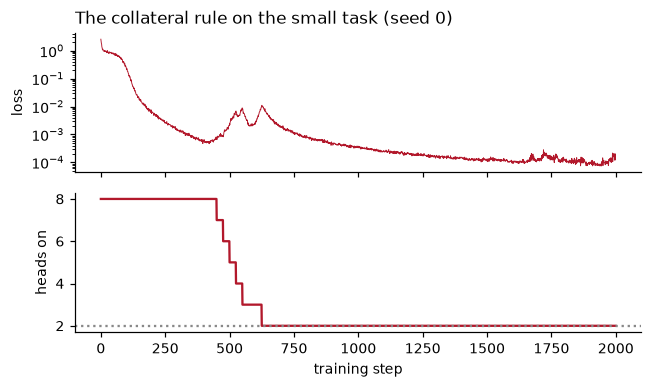

In [9]:
def train_rule(H=8, steps=2000, start=400, every=25, price=0.03, taper=50, seed=0):
    torch.manual_seed(seed)
    model = Heads(H)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    open_, tone = [True] * H, torch.ones(H)
    pq, pmem, pans, *_ = make_batch(512, torch.Generator().manual_seed(1))
    history = []
    for step in range(steps):
        q, mem, ans, *_ = make_batch(128)
        loss = F.mse_loss(model(q, mem, tone), ans)
        opt.zero_grad(); loss.backward(); opt.step()
        if step >= start and (step - start) % every == 0:
            with torch.no_grad():
                o = model.outputs(pq, pmem).numpy()
            values = collateral_values([o[:, h] for h in range(H)], pans.numpy(),
                                       [h for h in range(H) if open_[h]])
            cheapest = min(values, key=values.get)
            if sum(open_) > 1 and values[cheapest] < price:
                open_[cheapest] = False
        goal = torch.tensor([1.0 if o_ else 0.0 for o_ in open_])
        tone += (goal - tone).clamp(-1 / taper, 1 / taper)
        history.append((loss.item(), int((tone > 0).sum())))
    return open_, np.array(history)


runs = [train_rule(seed=s) for s in range(3)]
for s, (open_, hist) in enumerate(runs):
    print(f"seed {s}: heads kept {sum(open_)} of 8 (task needs {R});  final loss {hist[-50:, 0].mean():.4f}")

hist = runs[0][1]
fig, ax = plt.subplots(2, 1, figsize=(6, 3.6), sharex=True)
ax[0].semilogy(hist[:, 0], color=RED, lw=0.6); ax[0].set_ylabel("loss")
ax[1].plot(hist[:, 1], color=RED); ax[1].axhline(R, color=GREY, ls=":"); ax[1].set_ylabel("heads on")
ax[1].set_xlabel("training step")
ax[0].set_title("The collateral rule on the small task (seed 0)", loc="left")
plt.tight_layout(); plt.show()

That is the whole method in about 30 lines. On this small task it usually lands on the
right number of heads and occasionally keeps one spare. The full experiments below use the
same idea at a larger size, with more seeds and the controls.

## 8. What the full experiments found (main task, 32 heads)

The repo's version: 32 heads, $N = 16$, tasks needing $k^\star = 2, 3, 4, 6, 8$ heads, 10 seeds
each. The controls change one ingredient at a time:
- **ordinary importance**: value a head *without* letting the others adjust;
- **random choice**: close a head at the same moments, but chosen at random;
- **standard pruning** (Michel et al. 2019): remove the least important head until the loss
  gets worse.

Two numbers matter: did it keep **exactly** $k^\star$ heads, and did it **never break the
model** (never go back above the "solved" loss) while removing heads?

In [10]:
sys.path.insert(0, "../src")
from hemo.config import Cfg

DEFAULT = Cfg()
RUNS = [pickle.load(open(f, "rb")) for d in ("../results", "../results/proposal", "../results/confirm")
        for f in glob.glob(d + "/*.pkl")]
RUNS = [r for r in RUNS if isinstance(r, dict) and "hist" in r and "ledger" in r.get("hist", {})]
PIN = dict(task="multi_relation", steps=4000, d_k=32, demand="outnorm_ema", leak=0.0, probe_every=25,
           prune_stop=1, conserve=1, local_value="refit", plant_copies=0, head_dropout=0.0,
           trial=0, target_frac=0.02, budget_hold_frac=0.25, taper=0, price_frac=0.01)
get = lambda r, k: r["cfg"].get(k, getattr(DEFAULT, k))
runs_of = lambda **w: [r for r in RUNS if all(get(r, k) == v for k, v in {**PIN, **w}.items())]


def kept(r):
    on = (r["hist"]["ledger"] > 0).sum(1)
    return float(np.median(on[int(0.6 * len(on)):]))


def stayed_solved(r):
    h, bar = r["hist"], 0.02 * r["trivial"]
    ls = [l for s, l in zip(h["val_step"], h["val_loss"]) if s >= get(r, "budget_hold_frac") * get(r, "steps")]
    first = next((i for i, l in enumerate(ls) if l < bar), None)
    return first is not None and max(ls[first:]) <= bar


RULE = dict(supply="local", price_frac=0.03, taper=100, budget_hold_frac=0.1, conserve=0)
arms = {"collateral rule": (RULE, (2, 3, 4, 6, 8)),
        "ordinary importance": ({**RULE, "local_value": "ablate"}, (2, 4, 8)),
        "random choice": ({**RULE, "local_value": "random"}, (2, 4, 8)),
        "standard pruning": (dict(supply="prune"), (2, 3, 4, 6, 8))}
print(f"{'rule':<22}{'runs':>5}{'exact count':>13}{'never broke':>13}")
for name, (kw, sizes) in arms.items():
    rs = [r for k in sizes for r in runs_of(**kw, n_rel=k)]
    print(f"{name:<22}{len(rs):>5}{sum(kept(r) == get(r, 'n_rel') for r in rs):>9}/{len(rs)}"
          f"{sum(stayed_solved(r) for r in rs):>9}/{len(rs)}")

rule                   runs  exact count  never broke
collateral rule          50       47/50       50/50
ordinary importance      30        2/30       30/30
random choice            30       30/30        6/30
standard pruning         36       34/36        0/36


Only the collateral rule does both. Ordinary importance keeps redundant heads; random
choice and standard pruning get the count but break the model on the way. Two more checks
from the same runs: started with every head duplicated, the collateral rule keeps exactly 4
heads and never both copies of a pair (10 of 10 seeds), and the right count holds at every
price from 0.01 to 0.1.

## 9. Backup heads when heads can fail

**Idea.** If heads fail at random during training (each with chance $p$), a spare head
becomes worth something: it saves the task when another fails. Any $R$ working heads can do
the job (they blend all the answers), so a head is worth something only when, without it,
fewer than $R$ heads would be working:

$$v(B) = \frac{1-p}{R}\ \Pr\big[\text{fewer than } R \text{ of the other } B-1 \text{ heads work}\big].$$

The rule keeps adding heads while $v(B)$ is at least the price.

**By hand**, $R = 4$, $p = 0.1$, price $0.03$: with $B = 5$ heads, the other 4 all work with
chance $0.9^4 = 0.656$, so fewer than 4 work with chance $0.344$, and
$v(5) = 0.9 \times 0.344 / 4 = 0.077 > 0.03$: keep 5. With $B = 6$:
$v(6) = 0.9 \times 0.081 / 4 = 0.018 < 0.03$: stop. Prediction: **5 heads**.

**Your turn.** Write `predict(R, p, price)` with `math.comb` for the binomial probability,
and check it returns 5 for the example.

In [11]:
def predict(R, p, price=0.03):
    q = 1 - p
    def value(B):
        fewer = sum(comb(B - 1, a) * q ** a * p ** (B - 1 - a) for a in range(min(R - 1, B - 1) + 1))
        return q * fewer / R
    return max(B for B in range(1, 33) if value(B) >= price)


print("predicted heads kept, R = 4, p = 0.1:", predict(4, 0.1))
assert predict(4, 0.1) == 5
print("\nREAL RESULT (predictions written before the runs):")
print(f"{'R':>2} {'p':>5} {'predicted':>10} {'measured (per seed)':>22}")
for Rr in (2, 4):
    for pp in (0.05, 0.1, 0.2, 0.3):
        rs = runs_of(**RULE, n_rel=Rr, head_dropout=pp)
        print(f"{Rr:>2} {pp:>5} {predict(Rr, pp):>10} {str([int(kept(r)) for r in rs]):>22}")

predicted heads kept, R = 4, p = 0.1: 5

REAL RESULT (predictions written before the runs):
 R     p  predicted    measured (per seed)
 2  0.05          3              [3, 3, 3]
 2   0.1          3              [3, 3, 3]
 2   0.2          4              [4, 4, 4]
 2   0.3          4              [5, 4, 5]
 4  0.05          5              [5, 5, 4]
 4   0.1          5              [5, 5, 5]
 4   0.2          6              [6, 6, 6]
 4   0.3          7              [7, 7, 7]


## 10. A second circuit: two-layer induction

**Idea.** In a sequence like `... 45 26 38 57 ... 45 26 38 ?`, the next token is `57`: find
the earlier copy of the current token and copy what came after it. Language models learn
this with two heads in two layers:
- a **previous-token head** (layer 1): each position looks one step back, so position `57`
  learns "the token before me was `38`";
- an **induction head** (layer 2): at the current `38`, look for the position whose previous
  token was `38`, which is `57`, and copy it.

So the known answer is **one head in each layer**. One layer alone cannot do it, whatever its
size (checked: about 16% accuracy against 99.8% with one head per layer).

**By hand.** Sequence positions: `0:11 1:45 2:26 3:38 4:57 5:14 6:45 7:26 8:38`. At position 8
(token 38) the induction head should attend to position 4: the earlier 38 is at 3, plus one.

**Real result** (`src/hemo/induction.py`, 8 heads per layer, 10 seeds):

In [12]:
IND = [pickle.load(open(f, "rb")) for f in glob.glob("../results/induction/*.pkl")]


def kept_layers(r):
    h1 = r["sizes"][0]
    return int(r["kept"][:h1].sum()), int(r["kept"][h1:].sum())


def ind_group(**w):
    return [r for r in IND if all(r["cfg"].get(k, v if k != "probe" else "mse") == v for k, v in w.items())]


groups = {
    "first version (linear read-out values)": dict(rule="collateral", probe="mse", price_frac=0.03, steps=3000),
    "loss-based values, keep it solved": dict(rule="collateral", probe="logit_tone", price_mode="bar",
                                              price_frac=0.02, steps=6000, trial=0, squeeze_at=0.0),
    "... plus trial closure": dict(rule="collateral", probe="logit_tone", price_mode="bar",
                                   price_frac=0.02, steps=6000, trial=1),
}
for name, w in groups.items():
    rs = ind_group(**w)
    ks = [kept_layers(r) for r in rs]
    print(f"{name:<42} n={len(rs):>2}  exactly (1, 1): {sum(k == (1, 1) for k in ks)}/{len(rs)}"
          f"  solved: {sum(r['final_loss'] <= r['bar'] for r in rs)}/{len(rs)}  kept: {ks}")

first version (linear read-out values)     n=10  exactly (1, 1): 0/10  solved: 10/10  kept: [(3, 4), (3, 3), (2, 3), (2, 3), (3, 3), (3, 3), (3, 3), (2, 3), (3, 3), (3, 4)]
loss-based values, keep it solved          n=10  exactly (1, 1): 0/10  solved: 10/10  kept: [(2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1)]
... plus trial closure                     n=10  exactly (1, 1): 8/10  solved: 7/10  kept: [(1, 1), (1, 1), (1, 1), (3, 1), (1, 1), (1, 1), (1, 1), (2, 1), (1, 1), (1, 1)]


Every kept head has the right role. The loss-based version keeps **one** induction head but
**two** previous-token heads, because those two share the job and the network needs time to
move it onto one. Letting it try (trial closure) reaches exactly one head per layer in 8 of
10 runs, but the failed tries push the loss above the solved bar, so the model no longer
stays solved throughout. On induction the rule finds the right roles with one spare; the
exact minimum costs stability.

## 11. What holds, and what does not

**Holds**
- The task needs exactly $R$ heads, and the loss of every smaller model follows
  $(1 - k/R)$ (sections 3, 4).
- A head at zero supply is removed exactly (section 5).
- Valuing a head by what the others cannot cover removes duplicates that ordinary importance
  keeps (sections 6, 8).
- On the main task the collateral rule keeps exactly the needed heads and never breaks the
  model while pruning, unlike standard pruning (section 8).
- With random head failures it keeps the number of backups a simple formula predicts
  (section 9).

**Does not hold, or is not claimed**
- The "fixed total supply" from autoregulation is not needed (it was tested and dropped).
- Final loss is a few times higher than a fully trained dense model, at about a third of
  the compute.
- On induction it keeps one spare previous-token head; forcing the minimum costs stability
  (section 10).
- Only small synthetic tasks so far; no real language model yet.
- The biology is inspiration (collateral circulation, gradual vessel pruning), not evidence
  about the brain.